In [ ]:
import torch
torch.cuda.is_available()


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install torch torchvision torchaudio   # install PyTorch (if needed)
!pip install nnunetv2                      # install nnU-Net v2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
import os

# Base directory inside Google Drive
base_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUnet_dataset"

# Set environment variables
os.environ["nnUNet_raw"] = os.path.join(base_dir, "nnUNet_raw_data")
os.environ["nnUNet_preprocessed"] = os.path.join(base_dir, "nnUNet_preprocessed")
os.environ["nnUNet_results"] = os.path.join(base_dir, "nnUNet_results")

# Create necessary directories
for path in [os.environ["nnUNet_raw"], os.environ["nnUNet_preprocessed"], os.environ["nnUNet_results"]]:
    os.makedirs(path, exist_ok=True)

# Verify setup
!echo "✅ nnUNet_raw = $nnUNet_raw"
!echo "✅ nnUNet_preprocessed = $nnUNet_preprocessed"
!echo "✅ nnUNet_results = $nnUNet_results"


✅ nnUNet_raw = /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUnet_dataset/nnUNet_raw_data
✅ nnUNet_preprocessed = /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUnet_dataset/nnUNet_preprocessed
✅ nnUNet_results = /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUnet_dataset/nnUNet_results


In [ ]:
!nnUNetv2_predict -h  # This should display usage information



#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

usage: nnUNetv2_predict [-h] -i I -o O -d D [-p P] [-tr TR] -c C
                        [-f F [F ...]] [-step_size STEP_SIZE] [--disable_tta]
                        [--verbose] [--save_probabilities]
                        [--continue_prediction] [-chk CHK] [-npp NPP]
                        [-nps NPS]
                        [-prev_stage_predictions PREV_STAGE_PREDICTIONS]
                        [-num_parts NUM_PARTS] [-part_id PART_ID]
                        [-device DEVICE] [--disable_progress_bar]

Use this to run inference with nnU-Net. This function is used when you want to
manua

In [ ]:
!pip install nibabel


In [ ]:
!pip install nibabel batchgenerators nnunet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.6/276.6 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
  Created wheel for nnunet: filename=nnunet-1.7.1-py3-none-any.whl size=531260 sha256=848521766c00b645fce7093dce1d37f4d1f530b07dd4b2cd823e7c26151c02e3
  Stored in directory: /root/.cache/pip/wheels/96/24/6f/29ae4df3d7ad633127125dba95ba0e3ef10bfea39da3a0f44c
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=037b85ddda4b90695bb53fd635989fe8cea088ecaad044a4cbe1e9aec3324a1b
  Stored in directory: /root/.cache/pip/wheels/d4/33/ed/aaac5a347fb8d41679ca515b8f5c49dfdf49be15bdbb9a905d
Successfully built nnunet medpy


In [ ]:
!ls -lh /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/


total 13K
-rw------- 1 root root  492 Mar 18 07:33 dataset.json
drwx------ 2 root root 4.0K Mar 18 05:29 imagesTr
drwx------ 2 root root 4.0K Mar 18 07:27 imagesTs
drwx------ 2 root root 4.0K Mar 18 05:29 labelsTr


In [ ]:
import os

# Define the paths
nnUNet_raw = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw"
nnUNet_preprocessed = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_preprocessed"
nnUNet_results = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results"

# Set environment variables
os.environ["nnUNet_raw"] = nnUNet_raw
os.environ["nnUNet_preprocessed"] = nnUNet_preprocessed
os.environ["nnUNet_results"] = nnUNet_results

# Create directories if they don't exist
os.makedirs(nnUNet_raw, exist_ok=True)
os.makedirs(nnUNet_preprocessed, exist_ok=True)
os.makedirs(nnUNet_results, exist_ok=True)

print("✅ nnUNet environment variables set!")


✅ nnUNet environment variables set!


In [ ]:
!nnUNetv2_plan_and_preprocess -d 114 --verify_dataset_integrity


Fingerprint extraction...
Dataset114_MNMs
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [ 11. 239. 255.], 3d_lowres: [11, 239, 255]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 49, 'patch_size': (np.int64(256), np.int64(256)), 'median_image_size_in_voxels': array([239., 255.]), 'spacing': array([1., 1.]), 'normalization_schemes'

In [ ]:
!ls /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTr/ | wc -l


504


In [ ]:
!ls /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr/ | wc -l


720


In [ ]:
import nibabel as nib
import numpy as np
import os

# Define dataset paths
dataset_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs"  # Adjust if needed
label_dir = os.path.join(dataset_path, "labelsTr")
image_dir = os.path.join(dataset_path, "imagesTr")

# Function to count non-orthonormal affine matrices
def count_non_orthonormal(directory):
    non_orthonormal_count = 0
    total_files = 0

    print(f"\n🔍 Checking affine matrices in {directory}")
    for file in os.listdir(directory):
        if file.endswith(".nii.gz"):
            total_files += 1
            file_path = os.path.join(directory, file)
            nii = nib.load(file_path)
            affine = nii.affine

            # Extract rotation matrix
            rotation_matrix = affine[:3, :3]
            determinant = np.linalg.det(rotation_matrix)

            if not np.isclose(determinant, 1.0) and not np.isclose(determinant, -1.0):
                non_orthonormal_count += 1
                print(f"❌ {file} has a non-orthonormal affine (det = {determinant})")

    print(f"\n✅ Total files checked: {total_files}")
    print(f"❌ Non-orthonormal affine files: {non_orthonormal_count}\n")

    return non_orthonormal_count

# Count in both imagesTr and labelsTr
non_orthonormal_images = count_non_orthonormal(image_dir)
non_orthonormal_labels = count_non_orthonormal(label_dir)

# Final summary
total_non_orthonormal = non_orthonormal_images + non_orthonormal_labels
print(f"\n🚀 Summary:")
print(f"🔹 Non-orthonormal images: {non_orthonormal_images}")
print(f"🔹 Non-orthonormal labels: {non_orthonormal_labels}")
print(f"🔹 Total non-orthonormal files: {total_non_orthonormal}")


🔍 Checking affine matrices in /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTr

✅ Total files checked: 504
❌ Non-orthonormal affine files: 0


🔍 Checking affine matrices in /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr

✅ Total files checked: 720
❌ Non-orthonormal affine files: 0


🚀 Summary:
🔹 Non-orthonormal images: 0
🔹 Non-orthonormal labels: 0
🔹 Total non-orthonormal files: 0


train-test split

In [ ]:
!ls /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs/ | wc -l


216


##train

In [ ]:
!nnUNetv2_train Dataset114_MNMs 3d_fullres 0 --npz


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-03-18 07:41:48.743991: Using torch.compile...
2025-03-18 07:41:49.819301: do_dummy_2d_data_aug: True
2025-03-18 07:41:49.847523: Using splits from existing split file: /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_preprocessed/Dataset114_MNMs/s

#Inference with saving soft probabilities

In [ ]:
!nnUNetv2_predict -i /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs \
                 -o /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output2 \
                 -d Dataset114_MNMs \
                 -c 3d_fullres \
                 -f 0 \
                 -chk checkpoint_best.pth \
                 --save_probabilities


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 216 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 216 cases that I would like to predict

Predicting 002_SA_ES:
perform_everything_on_device: True
100% 1/1 [00:01<00:00,  1.06s/it]
sending off prediction to background worker for resampling and export
done with 002_SA_ES

Predicting 007_SA_ES:
perform_everything_on_device: True
100% 1/1 [00:00<00:00, 14.37it/s]
sending off prediction to background worker for resampling and export
done with 007_SA_ES

Predicting 009_SA_ED:
perform_everything_on_device: True
100% 1/1 [00

Inference

In [ ]:
!nnUNetv2_predict -i /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs \
                 -o /content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output \
                 -d Dataset114_MNMs \
                 -c 3d_fullres \
                 -f 0 \
                 -chk checkpoint_best.pth



#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 216 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 216 cases that I would like to predict

Predicting 002_SA_ES:
perform_everything_on_device: True
100% 1/1 [00:00<00:00,  1.12it/s]
sending off prediction to background worker for resampling and export
done with 002_SA_ES

Predicting 007_SA_ES:
perform_everything_on_device: True
100% 1/1 [00:00<00:00, 15.65it/s]
sending off prediction to background worker for resampling and export
done with 007_SA_ES

Predicting 009_SA_ED:
perform_everything_on_device: True
100% 1/1 [00

In [ ]:
!pip install numpy nibabel scikit-learn matplotlib


In [ ]:
import os

# Paths
test_images_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
ground_truth_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
predictions_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output"

# Get test filenames
test_files = sorted(os.listdir(test_images_path))
test_labels = [f.replace(".nii.gz", ".nii.gz") for f in test_files]  # Ensure matching format

print(f"Total test images: {len(test_files)}")
print("Example test files:", test_files[:5], test_labels[:5])


Total test images: 216
Example test files: ['002_SA_ES_0000.nii.gz', '007_SA_ES_0000.nii.gz', '009_SA_ED_0000.nii.gz', '011_SA_ES_0000.nii.gz', '013_SA_ED_0000.nii.gz'] ['002_SA_ES_0000.nii.gz', '007_SA_ES_0000.nii.gz', '009_SA_ED_0000.nii.gz', '011_SA_ES_0000.nii.gz', '013_SA_ED_0000.nii.gz']


In [ ]:
import numpy as np
import nibabel as nib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

# Paths
test_images_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
ground_truth_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
predictions_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output"

# Get list of prediction files
prediction_files = sorted(os.listdir(predictions_path))

# Initialize lists to store metrics
ious = []
dice_scores = []

# Function to compute Dice coefficient
def dice_coefficient(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-6)

# Loop through predictions and compare with ground truth
for pred_file in prediction_files:
    pred_file_path = os.path.join(predictions_path, pred_file)
    gt_file_path = os.path.join(ground_truth_path, pred_file)  # Matching label file

    # Check if ground truth exists
    if not os.path.exists(gt_file_path):
        print(f"⚠️ Skipping {pred_file}: No ground truth found.")
        continue

    # Load files
    pred_nifti = nib.load(pred_file_path).get_fdata()
    gt_nifti = nib.load(gt_file_path).get_fdata()

    # Convert to binary masks
    pred_mask = (pred_nifti > 0).astype(np.uint8)
    gt_mask = (gt_nifti > 0).astype(np.uint8)

    # Compute IoU
    iou = jaccard_score(gt_mask.flatten(), pred_mask.flatten(), average='macro')
    ious.append(iou)

    # Compute Dice Score
    dice = dice_coefficient(gt_mask, pred_mask)
    dice_scores.append(dice)

# Compute mean values
mean_iou = np.mean(ious)
mean_dice = np.mean(dice_scores)

print(f"✅ Mean IoU: {mean_iou:.4f}")
print(f"✅ Mean Dice Score: {mean_dice:.4f}")


⚠️ Skipping dataset.json: No ground truth found.
⚠️ Skipping plans.json: No ground truth found.
⚠️ Skipping predict_from_raw_data_args.json: No ground truth found.
✅ Mean IoU: 0.9510
✅ Mean Dice Score: 0.9497


In [ ]:
import os

# Paths
test_images_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
ground_truth_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
predictions_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output"

# Get test filenames (strip `_0000` to match labels and predictions)
test_files = sorted(os.listdir(test_images_path))
test_files_fixed = [f.replace("_0000.nii.gz", ".nii.gz") for f in test_files]

print(f"✅ Total test images: {len(test_files)}")
print("📂 Example test files (Fixed):", test_files_fixed[:5])

# Check filenames in predictions and labels
print("\n✅ Predictions:")
print(os.listdir(predictions_path)[:5])

print("\n✅ Ground Truth Labels:")
print(os.listdir(ground_truth_path)[:5])


✅ Total test images: 216
📂 Example test files (Fixed): ['002_SA_ES.nii.gz', '007_SA_ES.nii.gz', '009_SA_ED.nii.gz', '011_SA_ES.nii.gz', '013_SA_ED.nii.gz']

✅ Predictions:
['predict_from_raw_data_args.json', 'dataset.json', 'plans.json', '002_SA_ES.nii.gz', '007_SA_ES.nii.gz']

✅ Ground Truth Labels:
['039_SA_ED.nii.gz', '052_SA_ED.nii.gz', '041_SA_ES.nii.gz', '009_SA_ED.nii.gz', '021_SA_ES.nii.gz']


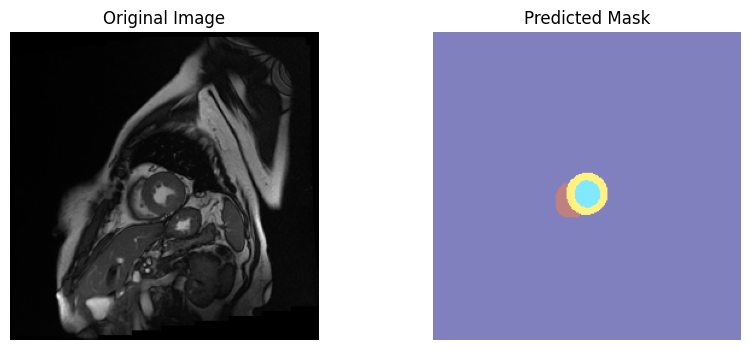

In [ ]:
import matplotlib.pyplot as plt

def visualize_prediction(image_file):
    image_file_fixed = image_file.replace("_0000.nii.gz", ".nii.gz")

    image_path = os.path.join(test_images_path, image_file)
    pred_path = os.path.join(predictions_path, image_file_fixed)

    # Load image and prediction
    image = nib.load(image_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    slice_idx = image.shape[2] // 2  # Pick middle slice

    plt.figure(figsize=(10, 4))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(image[:, :, slice_idx], cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    # Predicted Mask
    plt.subplot(1, 2, 2)
    plt.imshow(pred[:, :, slice_idx], cmap="jet", alpha=0.5)
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

# Pick a random test file
sample_file = test_files[0]
visualize_prediction(sample_file)


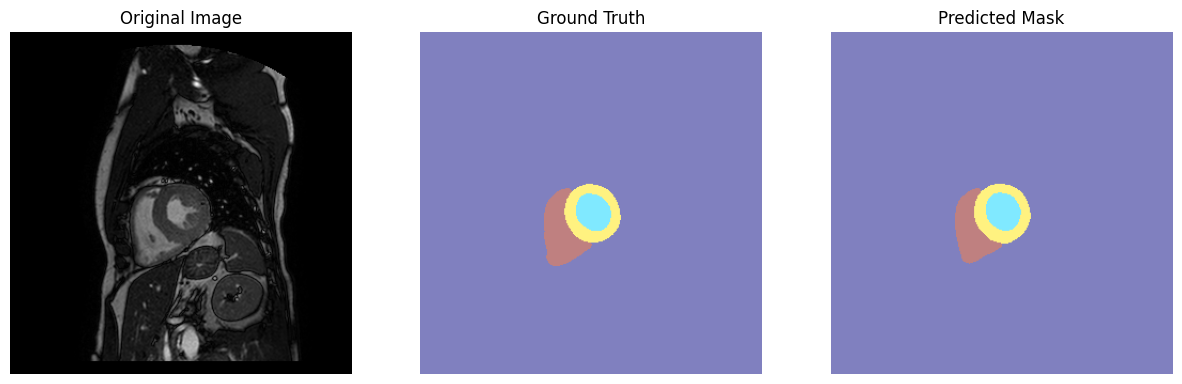

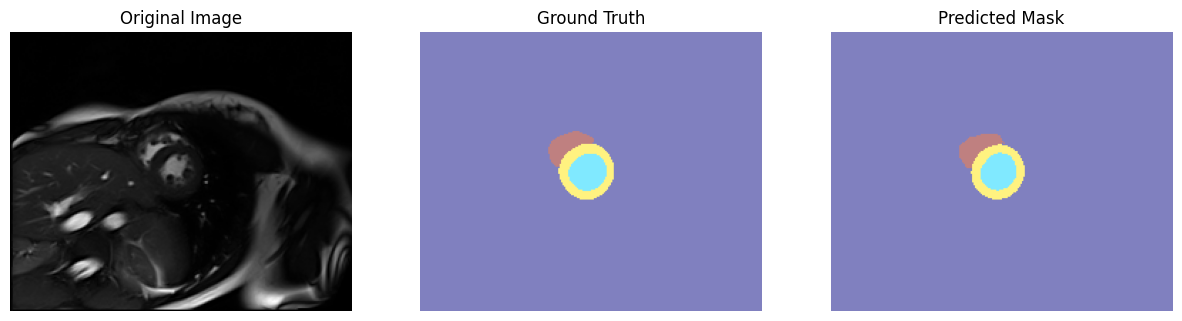

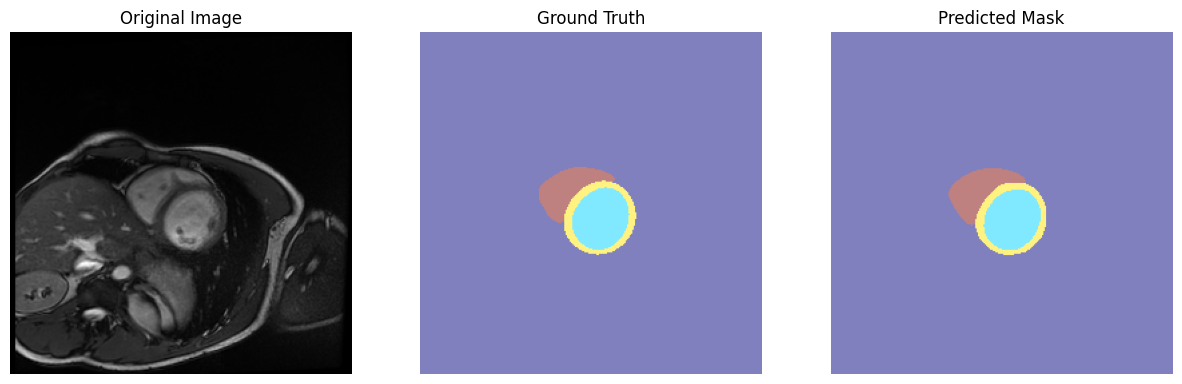

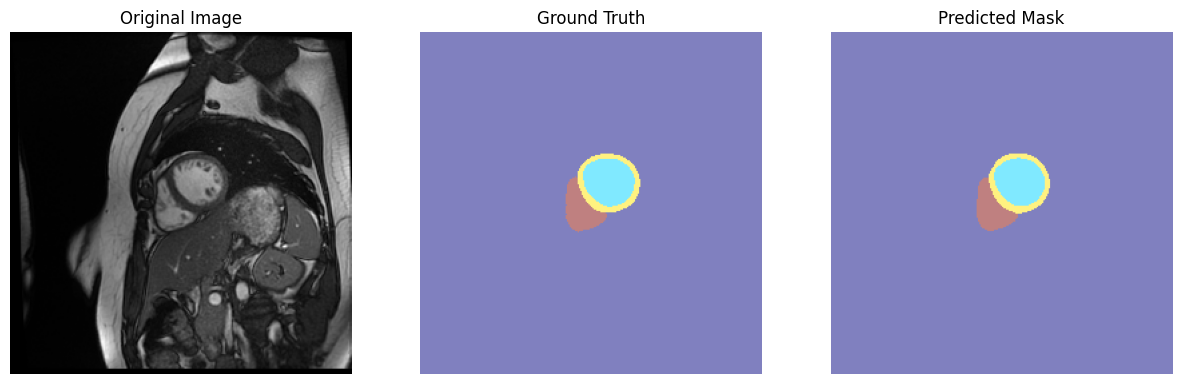

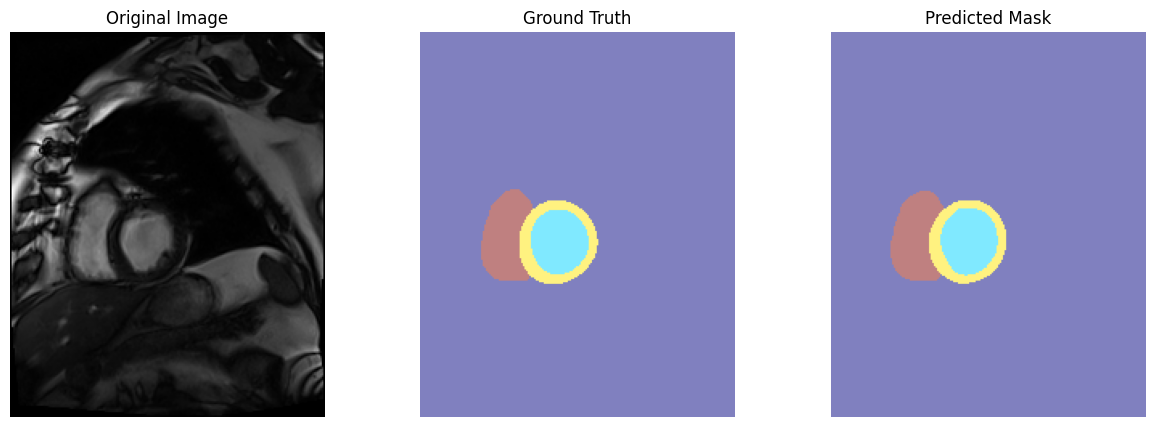

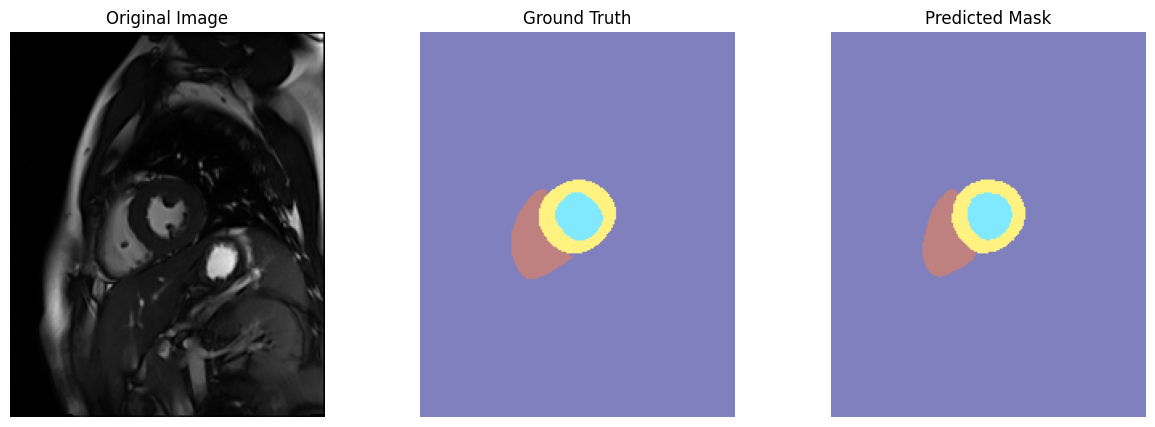

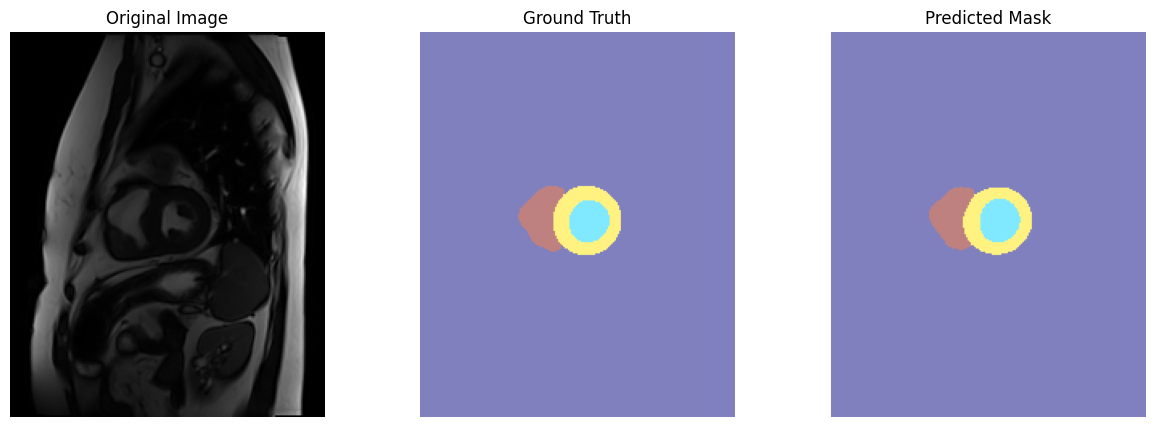

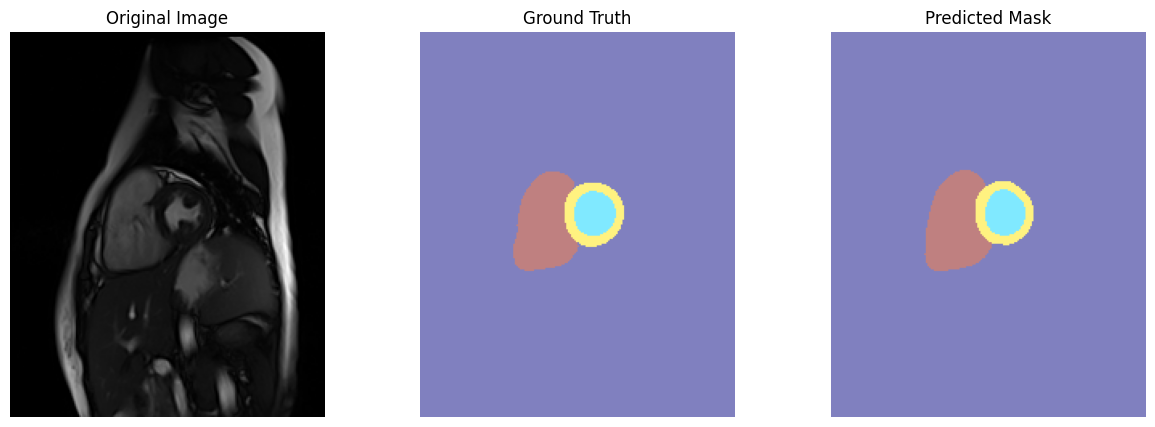

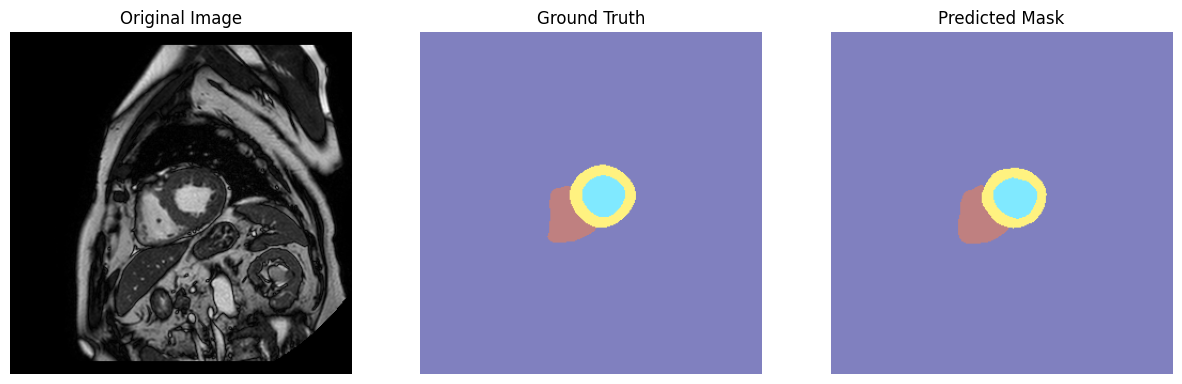

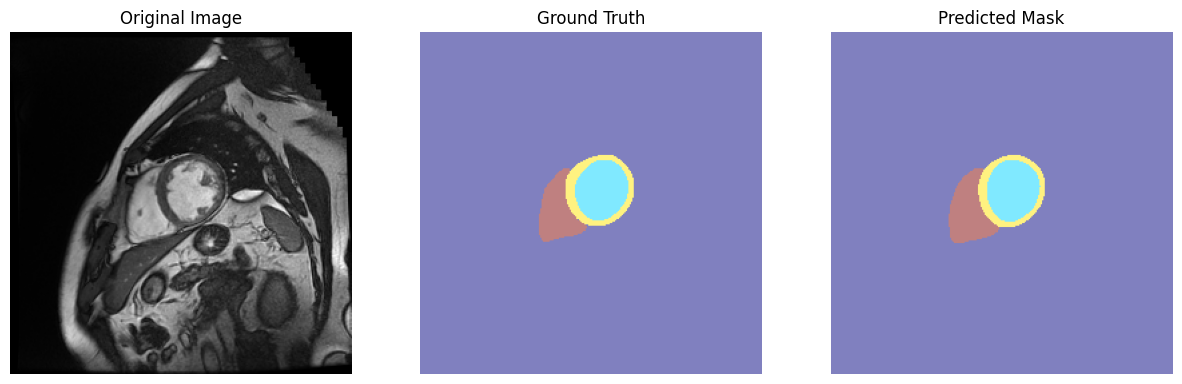

In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import random

# Paths
test_images_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
ground_truth_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
predictions_path = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output"

# Get test filenames
test_files = sorted(os.listdir(test_images_path))

# Select 10 random images
random_files = random.sample(test_files, 10)

def visualize_predictions(image_files):
    for image_file in image_files:
        image_file_fixed = image_file.replace("_0000.nii.gz", ".nii.gz")  # Match prediction format

        image_path = os.path.join(test_images_path, image_file)
        pred_path = os.path.join(predictions_path, image_file_fixed)
        gt_path = os.path.join(ground_truth_path, image_file_fixed)  # Ensure labels exist

        # Load image, prediction, and ground truth
        image = nib.load(image_path).get_fdata()
        pred = nib.load(pred_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()

        slice_idx = image.shape[2] // 2  # Pick middle slice

        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(image[:, :, slice_idx], cmap="gray")
        plt.title("Original Image")
        plt.axis("off")

        # Ground Truth
        plt.subplot(1, 3, 2)
        plt.imshow(gt[:, :, slice_idx], cmap="jet", alpha=0.5)
        plt.title("Ground Truth")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(pred[:, :, slice_idx], cmap="jet", alpha=0.5)
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.show()

# Visualize 10 samples
visualize_predictions(random_files)
